# Simulating Two-Pixel System

In [1]:
# Import libraries
from quspin.operators import hamiltonian, quantum_operator, quantum_LinearOperator, ishamiltonian
from quspin.basis import spin_basis_1d, tensor_basis
from quspin.tools.measurements import ent_entropy, diag_ensemble, obs_vs_time
from quspin.tools.misc import mean_level_spacing

from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import curve_fit, minimize
from scipy.stats import gaussian_kde
from tqdm import tqdm

from core import *

# Set default plot parameters
plt.rcParams["font.size"] = 18
plt.rcParams["font.family"] = "Arial"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

# Set random seed for reproducibility
rng = np.random.default_rng(42)

## Hamiltonian operator construction

In [2]:
def construct_two_pixel_hamiltonian_analyzer(L, hx, hz, h1, hL, g):
    """
    Constructs the total HamiltonianAnalyzer for the system with and two pixels.

    Parameters:
        L (int): Number of spins in each pixel.
        hx (float): X latch-field strength on the pixel.
        hz (float): Z latch-field strength on the pixel.
        h1 (float): Z field strength on the first spin of each pixel.
        hL (float): Z field strength on the last spin of each pixel.
        g (float): Qubit-pixel coupling strength.

    Returns:
        HamiltonianAnalyzer: Analyzer object for the two-pixel Hamiltonian.
    """
    # Basis for the qubit (site 0), pixel #1 (sites 1,...,L) and pixel #2 (sites L+1,...,2L)
    basis_list = [("spin", 1, True, {}), ("spin", L, True, {}), ("spin", L, True, {})]
    ha = HamiltonianAnalyzer(basis_list=basis_list)

    # Nearest-neighbor 1D Ising interaction (open BC) in each pixel
    ha.add_static_term(coeff=1., op_str="|zz|", sites=[[i, i + 1] for i in range(L - 1)])
    ha.add_static_term(coeff=1., op_str="||zz", sites=[[i, i + 1] for i in range(L - 1)])

    # "Latch" interaction between the qubit and each pixel
    ha.add_static_term(coeff=hx / 2, op_str="|x|", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=hz / 2, op_str="|z|", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=hx / 2, op_str="z|x|", sites=[[0, i] for i in range(L)])
    ha.add_static_term(coeff=hz / 2, op_str="z|z|", sites=[[0, i] for i in range(L)])
    ha.add_static_term(coeff=hx / 2, op_str="||x", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=hz / 2, op_str="||z", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=-hx / 2, op_str="z||x", sites=[[0, i] for i in range(L)])
    ha.add_static_term(coeff=-hz / 2, op_str="z||z", sites=[[0, i] for i in range(L)])

    # Additional Z-field on the boundary of each pixel
    ha.add_static_term(coeff=h1, op_str="|z|", sites=[[0]])
    ha.add_static_term(coeff=hL, op_str="|z|", sites=[[L - 1]])
    ha.add_static_term(coeff=h1, op_str="||z", sites=[[0]])
    ha.add_static_term(coeff=hL, op_str="||z", sites=[[L - 1]])

    # Additional xz interaction between the qubit and each pixel
    ha.add_static_term(coeff=g, op_str="x|x|", sites=[[0, i] for i in range(L)])
    ha.add_static_term(coeff=g, op_str="x||x", sites=[[0, i] for i in range(L)])

    return ha

## Observable definition

In [3]:
def collective_pauli(basis, system_idx, coord):
    """
    Constructs the collective Pauli operator for the specified subsystem in the two-pixel system.

    Parameters:
        basis: The tensor basis object for the system.
        system_idx (int): Index of the subsystem (0 for qubit, 1 for pixel #1, 2 for pixel #2).
        coord (str): Pauli operator coordinate ('x', 'y', or 'z').

    Returns:
        hamiltonian: The collective Pauli operator as a QuSpin hamiltonian object.

    Raises:
        ValueError: If system_idx is not 0, 1, or 2.
    """
    L = basis.N[system_idx]

    dtype = np.float64 if coord in ["x", "z"] else np.complex128

    # Qubit operator
    if system_idx == 0:
        return hamiltonian([[f"{coord}||", [[1., 0]]]], [], basis=basis, dtype=dtype,
                           check_symm=False, check_herm=False, check_pcon=False)
    
    # Pixel #1 operator
    elif system_idx == 1:
        return hamiltonian([[f"|{coord}|", [[1. / L, i] for i in range(L)]]], [], basis=basis, dtype=dtype,
                           check_symm=False, check_herm=False, check_pcon=False)
    
    # Pixel #2 operator
    elif system_idx == 2:
        return hamiltonian([[f"||{coord}", [[1. / L, i] for i in range(L)]]], [], basis=basis, dtype=dtype,
                           check_symm=False, check_herm=False, check_pcon=False)
    
    else:
        raise ValueError("Invalid system index. Must be 0 (qubit), 1 (pixel #1), or 2 (pixel #2).")
    
def no_qubit_pauli(basis_no_qubit, pixel_idx, coord):
    """
    Constructs the collective Pauli operator for a pixel subsystem in the system without the qubit.

    Parameters:
        basis_no_qubit: The tensor basis object for the system without the qubit.
        pixel_idx (int): Index of the pixel subsystem (1 for pixel #1, 2 for pixel #2).
        coord (str): Pauli operator coordinate ('x', 'y', or 'z').

    Returns:
        hamiltonian: The collective Pauli operator as a QuSpin hamiltonian object.

    Raises:
        ValueError: If pixel_idx is not 1 or 2.
    """
    L = basis_no_qubit.N[1]

    dtype = np.float64 if coord in ["x", "z"] else np.complex128
    
    # Pixel #1 operator
    if pixel_idx == 1:
        return hamiltonian([[f"{coord}|", [[1. / L, i] for i in range(L)]]], [], basis=basis_no_qubit, dtype=dtype,
                           check_symm=False, check_herm=False, check_pcon=False)
    
    # Pixel #2 operator
    elif pixel_idx == 2:
        return hamiltonian([[f"|{coord}", [[1. / L, i] for i in range(L)]]], [], basis=basis_no_qubit, dtype=dtype,
                           check_symm=False, check_herm=False, check_pcon=False)

    else:
        raise ValueError("Invalid pixel index. Must be 1 (pixel #1) or 2 (pixel #2).")

## Time evolution

In [4]:
def compute_time_evolution_pauli(ha, times, psi0, obs_dict=None, eigvals=None, eigvecs=None, verbose=False, return_state=False):
    """
    Computes the time evolution of collective Pauli observables for a two-pixel system.

    Parameters:
        ha: HamiltonianAnalyzer object for the system.
        times (array-like): Array of time points for evolution.
        psi0 (np.ndarray): Initial state vector of the system.
        obs_dict (dict, optional): Dictionary of observables to measure. If None, uses default collective Pauli operators.
        eigvals (np.ndarray, optional): Eigenvalues of the Hamiltonian. If None, will be computed.
        eigvecs (np.ndarray, optional): Eigenvectors of the Hamiltonian. If None, will be computed.
        verbose (bool, optional): If True, prints progress information.
        return_state (bool, optional): If True, returns the evolved state at each time.

    Returns:
        dict: Dictionary containing time evolution of observables (and optionally state_t if return_state=True).
    """
    # Diagonalize the Hamiltonian if necessary
    if eigvals is None or eigvecs is None:
        eigvals, eigvecs = ha.diagonalize()

    # Default observables: collective Pauli operators for each subsystem
    if obs_dict is None:
        obs_dict = {f"{coord}{i}": collective_pauli(ha.basis, i, coord) for coord in ["x", "y", "z"] for i in range(3)}

    obs_time = obs_vs_time(psi_t=(psi0, eigvals, eigvecs),
                           times=times, Obs_dict=obs_dict, verbose=verbose,
                           return_state=return_state)

    # Convert observables to real values
    for obs in obs_time:
        if obs != "psi_t":
            obs_time[obs] = np.real_if_close(obs_time[obs])

    return obs_time

In [45]:
# Simulate time evolution
L = 5  # Number of spins in each pixel
hx = 1.1  # X latch-field strength on the pixel
hz = -0.3  # Z latch-field strength on the pixel
h1 = 0.0  # Z field strength on the first spin of each pixel
hL = 0.0  # Z field strength on the last spin of each pixel
g = 0.15  # Qubit-pixel coupling strength

ha = construct_two_pixel_hamiltonian_analyzer(L=L, hx=hx, hz=hz, h1=h1, hL=hL, g=g)
E, V = ha.diagonalize(timeit=True)
Ns = ha.basis.Ns

dt = 0.1
times = np.arange(0, 50, dt)

obs_dict = {f"z{i}": collective_pauli(ha.basis, i, "z") for i in range(3)}

# Qubit in |0>
psi0 = np.zeros(Ns, dtype=np.complex128)
psi0[0] = 1.
obs_time_0 = compute_time_evolution_pauli(ha, times=times, psi0=psi0, eigvals=E, eigvecs=V, obs_dict=obs_dict, verbose=True, return_state=False)

# Qubit in |1>
psi0 = np.zeros(Ns, dtype=np.complex128)
psi0[Ns // 2] = 1.
obs_time_1 = compute_time_evolution_pauli(ha, times=times, psi0=psi0, eigvals=E, eigvecs=V, obs_dict=obs_dict, verbose=True, return_state=False)

Diagonalization took 10.5336 seconds.
obs_vs_time integrated to t=0.1000
obs_vs_time integrated to t=0.2000
obs_vs_time integrated to t=0.3000
obs_vs_time integrated to t=0.4000
obs_vs_time integrated to t=0.5000
obs_vs_time integrated to t=0.6000
obs_vs_time integrated to t=0.7000
obs_vs_time integrated to t=0.8000
obs_vs_time integrated to t=0.9000
obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=1.1000
obs_vs_time integrated to t=1.2000
obs_vs_time integrated to t=1.3000
obs_vs_time integrated to t=1.4000
obs_vs_time integrated to t=1.5000
obs_vs_time integrated to t=1.6000
obs_vs_time integrated to t=1.7000
obs_vs_time integrated to t=1.8000
obs_vs_time integrated to t=1.9000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=2.1000
obs_vs_time integrated to t=2.2000
obs_vs_time integrated to t=2.3000
obs_vs_time integrated to t=2.4000
obs_vs_time integrated to t=2.5000
obs_vs_time integrated to t=2.6000
obs_vs_time integrated to t=2.7000
obs_vs_time integ

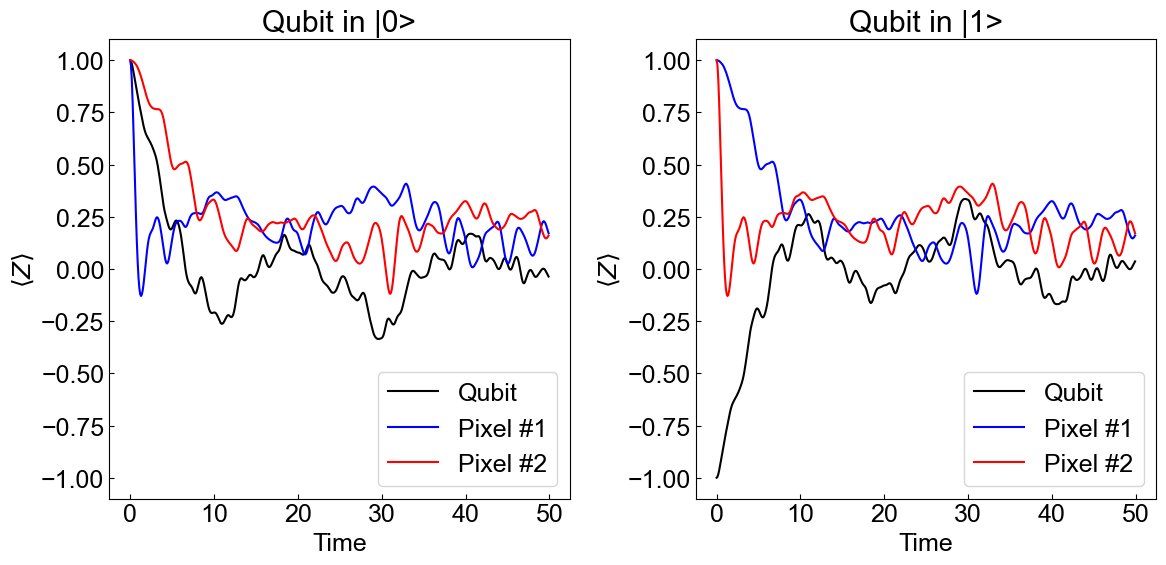

In [48]:
# Visualize results
fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=100)
axs[0].plot(times, obs_time_0["z0"], color="k", label="Qubit")
axs[0].plot(times, obs_time_0["z1"], color="b", label="Pixel #1")
axs[0].plot(times, obs_time_0["z2"], color="r", label="Pixel #2")
axs[0].set_title("Qubit in |0>")

axs[1].plot(times, obs_time_1["z0"], color="k", label="Qubit")
axs[1].plot(times, obs_time_1["z1"], color="b", label="Pixel #1")
axs[1].plot(times, obs_time_1["z2"], color="r", label="Pixel #2")
axs[1].set_title("Qubit in |1>")

for ax in axs:
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Time")
    ax.set_ylabel(r"$\langle Z \rangle$")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Loschmidt echo sanity check

In [5]:
def compute_loschmidt_echo(ha, psi0, times, eigvals=None, eigvecs=None):
    """
    Computes the Loschmidt echo for a quantum system described by HamiltonianAnalyzer.

    The Loschmidt echo quantifies the overlap between the initial state and the state evolved forward in time and then backward under the reversed Hamiltonian.

    Parameters:
        ha: HamiltonianAnalyzer object for the system.
        psi0 (np.ndarray): Initial state vector of the system.
        times (array-like): Array of time points for evolution.
        eigvals (np.ndarray, optional): Eigenvalues of the Hamiltonian. If None, will be computed.
        eigvecs (np.ndarray, optional): Eigenvectors of the Hamiltonian. If None, will be computed.

    Returns:
        list: Loschmidt echo values at each time in `times`.
    """
    # Diagonalize Hamiltonian if necessary
    if eigvals is None or eigvecs is None:
        eigvals, eigvecs = ha.diagonalize()

    # Compute forward evolution
    print("Computing forward evolution...")
    obs_time_forward = compute_time_evolution_pauli(ha, times=times, psi0=psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=False, return_state=True)
    psi_t_forward = obs_time_forward["psi_t"]

    # Compute backward evolution
    psi_t_backward = []
    for t_idx, t in tqdm(enumerate(times), desc="Computing backward evolution...", total=len(times)):
        obs_backward = compute_time_evolution_pauli(ha, times=[t], psi0=psi_t_forward[:, t_idx], eigvals=-eigvals, eigvecs=eigvecs, verbose=False, return_state=True)
        psi_t_backward.append(obs_backward["psi_t"])

    # Compute Loschmidt echo
    loschmidt_echo = [np.abs(np.vdot(psi0, psi_t_backward[t_idx])) ** 2 for t_idx in range(len(times))]
    return loschmidt_echo

In [40]:
# Evaluate Loschmidt echo for integrable and non-integrable (chaotic) cases
L = 5
psi0 = np.zeros(2 ** (2 * L + 1), dtype=np.complex128)
psi0[0] = 1.
times = np.logspace(0, 6, 101)

# Integrable (nonzero hx, zero hz)
hx_int = 1.1
hz_int = 0.0
ha_int = construct_two_pixel_hamiltonian_analyzer(L=L, hx=hx_int, hz=hz_int, h1=0, hL=0, g=0.15)
l_int = compute_loschmidt_echo(ha_int, psi0=psi0, times=times)

# Non-integrable (nonzero hx, nonzero hz)
hx_chaos = 1.1
hz_chaos = -0.3
ha_chaos = construct_two_pixel_hamiltonian_analyzer(L=L, hx=hx_chaos, hz=hz_chaos, h1=0, hL=0, g=0.15)
l_chaos = compute_loschmidt_echo(ha_chaos, psi0=psi0, times=times)

Computing forward evolution...


Computing backward evolution...: 100%|██████████| 101/101 [00:26<00:00,  3.77it/s]


Computing forward evolution...


Computing backward evolution...: 100%|██████████| 101/101 [00:21<00:00,  4.79it/s]


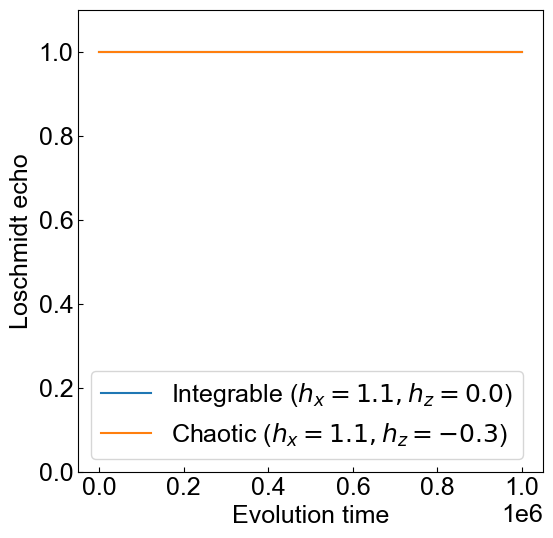

In [42]:
# Visualize Loschmidt echo in both cases
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
ax.plot(times, l_int, label=f"Integrable ($h_x={hx_int},h_z={hz_int}$)", color="C0")
ax.plot(times, l_chaos, label=f"Chaotic ($h_x={hx_chaos},h_z={hz_chaos}$)", color="C1")
ax.set_ylim(0, 1.1)
ax.set_xlabel("Evolution time")
ax.set_ylabel("Loschmidt echo")
ax.legend()
plt.show()

## Backward propagation of system dynamics

In [5]:
def create_final_collapsed_state(L, qubit_state, seed=0):
    """
    Creates the final collapsed state for a two-pixel system.

    Parameters:
        L (int): Number of spins in each pixel.
        qubit_state (int): Qubit state (0 for |0>, 1 for |1>).
        seed (int, optional): Random seed for the melted pixel state.

    Returns:
        np.ndarray: State vector of the full system (shape (2 * 2**L * 2**L,)).
    """
    psi_qubit = np.array([1, 0], dtype=np.complex128) if qubit_state == 0 else np.array([0, 1], dtype=np.complex128)
    psi_pixel_aligned = np.zeros(2**L, dtype=np.complex128)
    psi_pixel_aligned[0] = 1.
    psi_pixel_melted = StateGenerator().create_haar_random_state(L, seed=seed)
    if qubit_state == 0:
        psi_total = np.kron(psi_qubit, np.kron(psi_pixel_melted, psi_pixel_aligned))
    elif qubit_state == 1:
        psi_total = np.kron(psi_qubit, np.kron(psi_pixel_aligned, psi_pixel_melted))
    else:
        raise ValueError("Invalid qubit state. Must be 0 or 1.")
    return psi_total

def compute_backward_time_evolution(ha, times_backward, qubit_state, eigvals=None, eigvecs=None, seed=0):
    """
    Computes the backward time evolution of a two-pixel system starting from the final collapsed state.

    Parameters:
        ha: HamiltonianAnalyzer object for the system.
        times_backward (array-like): Array of negative time points for backward evolution.
        qubit_state (int): Qubit state (0 for |0>, 1 for |1>).
        eigvals (np.ndarray, optional): Eigenvalues of the Hamiltonian. If None, will be computed.
        eigvecs (np.ndarray, optional): Eigenvectors of the Hamiltonian. If None, will be computed.
        seed (int, optional): Random seed for the melted pixel state.

    Returns:
        np.ndarray: State vector of the system at each time point (shape (len(times_backward), 2 * 2**L * 2**L)).
    """

    # Diagonalize the Hamiltonian if necessary
    if eigvals is None or eigvecs is None:
        eigvals, eigvecs = ha.compute_eigenstates()

    # Create "final" state
    L = ha.basis.N[1]  # Number of spins in each pixel
    final_state = create_final_collapsed_state(L, qubit_state, seed=seed)

    # Compute backward time evolution
    obs_time = compute_time_evolution_pauli(ha, times=times_backward, psi0=final_state, eigvals=-eigvals, eigvecs=eigvecs, verbose=True, return_state=True)

    # Extract pixel states conditioned on qubit value
    Ns = ha.basis.Ns
    psi_t_0, psi_t_1 = obs_time["psi_t"][:Ns // 2, :], obs_time["psi_t"][Ns // 2:, :]
    psi_t_0 /= np.linalg.norm(psi_t_0, axis=0)
    psi_t_1 /= np.linalg.norm(psi_t_1, axis=0)

    # Compute average Z magnetization on conditioned pixel states
    basis_single_pixel = spin_basis_1d(L, pauli=True)
    basis_two_pixel = tensor_basis(basis_single_pixel, basis_single_pixel)
    z_pixel_1 = no_qubit_pauli(basis_two_pixel, pixel_idx=1, coord="z")
    z_pixel_2 = no_qubit_pauli(basis_two_pixel, pixel_idx=2, coord="z")

    obs_time["z1_cond_0"] = np.real_if_close(z_pixel_1.expt_value(psi_t_0, enforce_pure=True))
    obs_time["z2_cond_0"] = np.real_if_close(z_pixel_2.expt_value(psi_t_0, enforce_pure=True))
    obs_time["z1_cond_1"] = np.real_if_close(z_pixel_1.expt_value(psi_t_1, enforce_pure=True))
    obs_time["z2_cond_1"] = np.real_if_close(z_pixel_2.expt_value(psi_t_1, enforce_pure=True))

    # Compute entanglement entropy between the two pixels
    obs_time["ent_entropy_cond_0"] = basis_two_pixel.ent_entropy(psi_t_0, enforce_pure=True)["Sent_A"]
    obs_time["ent_entropy_cond_1"] = basis_two_pixel.ent_entropy(psi_t_1, enforce_pure=True)["Sent_A"]

    # Remove state vector for memory efficiency
    del obs_time["psi_t"]

    return obs_time

In [119]:
# Simulate backward time evolution
# System parameters
L = 5  # Number of spins in each pixel
hx = 1.1  # X latch-field strength on the pixel
hz = -0.3  # Z field strength on the pixel
h1 = 0.25  # Z field strength on the first spin of each pixel
hL = -0.25  # Z field strength on the last spin of each pixel
g = 0.15  # Qubit-pixel coupling strength

ha = construct_two_pixel_hamiltonian_analyzer(L=L, hx=hx, hz=hz, h1=h1, hL=hL, g=g)
E, V = ha.diagonalize(timeit=True)

dt = 0.1
times_backward = np.array([0, 1, 2, 5, 10, 20, 50, 100])
# times_backward = np.arange(0, 100 + dt, dt)
num_realizations = 10 ** 4

obs_time_lst = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_backward_time_evolution)(
        ha=ha, times_backward=times_backward, qubit_state=0, eigvals=E, eigvecs=V, seed=i
    ) for i in range(num_realizations))

Diagonalization took 4.2314 seconds.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   13.1s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   13.7s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   14.5s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   15.0s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   15.9s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   16.6s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:   17.7s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   18.5s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:   20.1s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:   21.4s
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:   23.0s
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:   24.3s
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:   26.1s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:   27.7s
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:   29.6s
[Parallel(

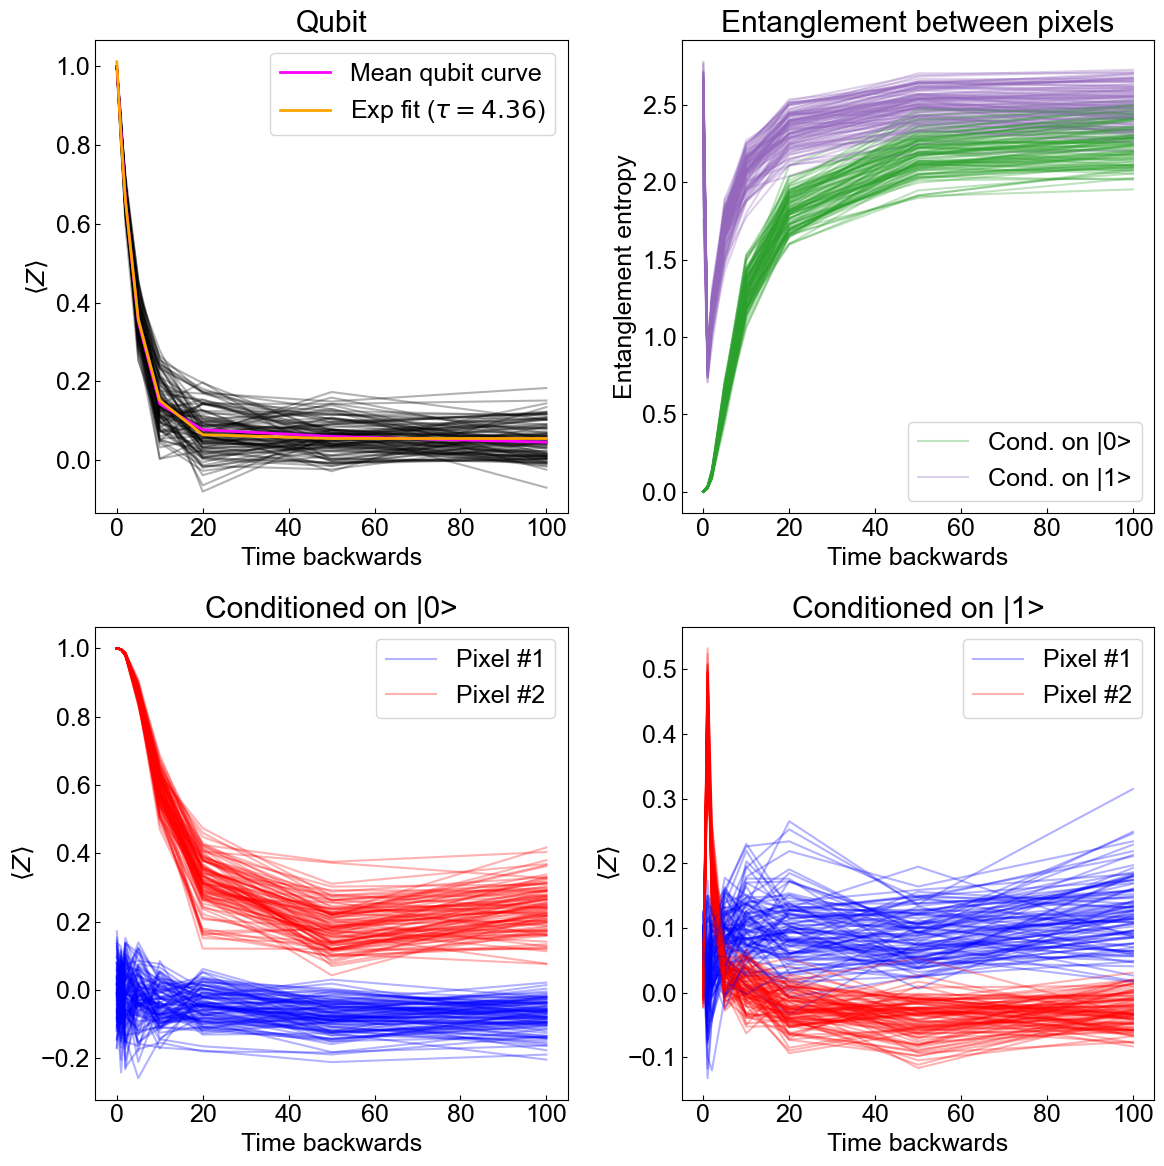

In [120]:
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=100)
t_mask = (times_backward <= 100)

for i in range(num_realizations)[:100]:
    obs_time = obs_time_lst[i]
    axs[0, 0].plot(times_backward[t_mask], obs_time["z0"][t_mask], color="k", alpha=0.3)

    axs[0, 1].plot(times_backward[t_mask], obs_time["ent_entropy_cond_0"][t_mask], color="C2", alpha=0.3)
    axs[0, 1].plot(times_backward[t_mask], obs_time["ent_entropy_cond_1"][t_mask], color="C4", alpha=0.3)

    axs[1, 0].plot(times_backward[t_mask], obs_time["z1_cond_0"][t_mask], color="b", alpha=0.3)
    axs[1, 0].plot(times_backward[t_mask], obs_time["z2_cond_0"][t_mask], color="r", alpha=0.3)
    axs[1, 1].plot(times_backward[t_mask], obs_time["z1_cond_1"][t_mask], color="b", alpha=0.3)
    axs[1, 1].plot(times_backward[t_mask], obs_time["z2_cond_1"][t_mask], color="r", alpha=0.3)

# Fit exponential to the mean qubit curve
qubit_mean = sum([obs_time["z0"] for obs_time in obs_time_lst]) / num_realizations
popt, _ = curve_fit(exp_decay, times_backward[t_mask], qubit_mean, p0=(1, 20, 0))

axs[0, 0].plot(times_backward[t_mask], qubit_mean, color="magenta", lw=2, label="Mean qubit curve")
axs[0, 0].plot(times_backward[t_mask], exp_decay(times_backward[t_mask], *popt), color="orange", lw=2, label=f"Exp fit ($\\tau={popt[1]:.2f}$)")

for ax in axs.flatten():
    ax.set_xlabel("Time backwards")
    ax.set_ylabel(r"$\langle Z \rangle$")

axs[0, 1].set_ylabel("Entanglement entropy")

axs[0, 0].set_title("Qubit")
axs[0, 1].set_title("Entanglement between pixels")
axs[1, 0].set_title("Conditioned on |0>")
axs[1, 1].set_title("Conditioned on |1>")

axs[0, 0].legend()
axs[0, 1].legend(["Cond. on |0>", "Cond. on |1>"])
axs[1, 0].legend(["Pixel #1", "Pixel #2"])
axs[1, 1].legend(["Pixel #1", "Pixel #2"])

plt.tight_layout()
plt.show()


## Characterizing the "purple algebra"

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

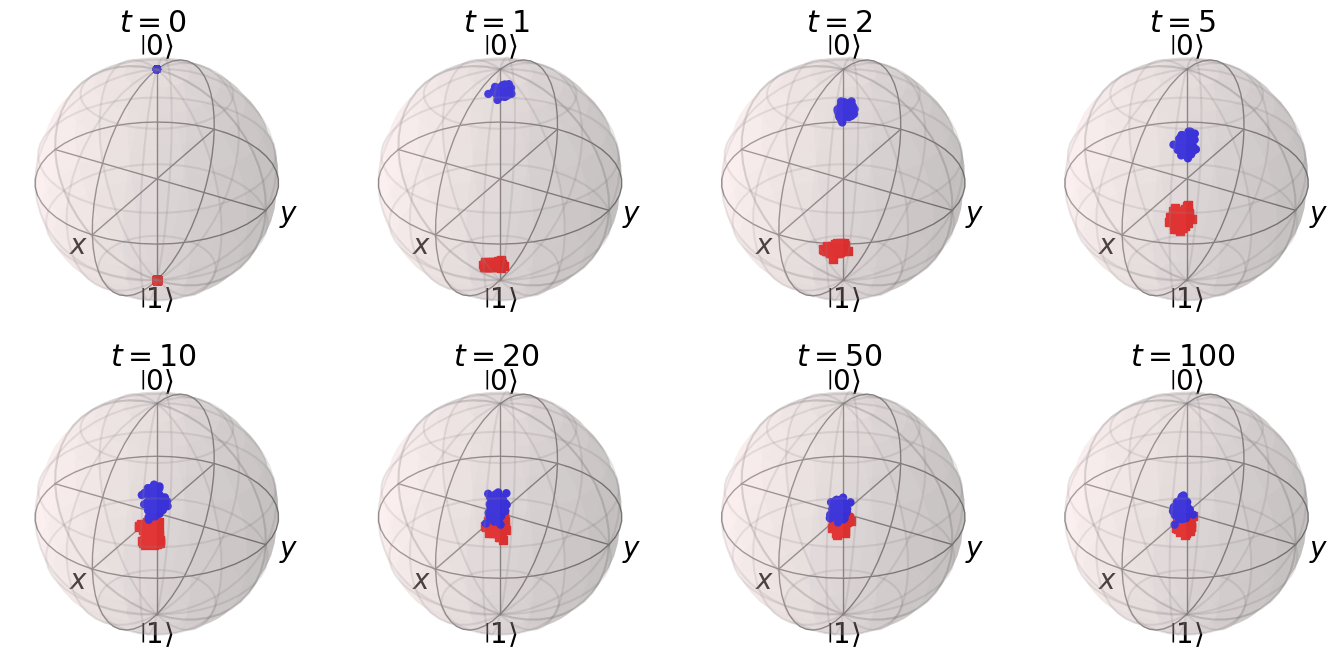

In [121]:
# Visualize qubit state on Bloch ball at different times
from mpl_toolkits.mplot3d import Axes3D

def plot_points_on_bloch_ball(fig, ax, *pnts_lst):
    b = Bloch()
    for pnts in pnts_lst:
        b.add_points(pnts)
    b.axes = ax
    b.show()

fig = plt.figure(figsize=(14, 7), dpi=100)
for i in range(len(times_backward)):
    ax = fig.add_subplot(2, 4, i + 1, projection="3d")
    pnts_x = np.array([obs_time["x0"][i] for obs_time in obs_time_lst[:100]])
    pnts_y = np.array([obs_time["y0"][i] for obs_time in obs_time_lst[:100]])
    pnts_z = np.array([obs_time["z0"][i] for obs_time in obs_time_lst[:100]])
    pnts = [pnts_x, pnts_y, pnts_z]
    pnts_flip = [pnts_x, -pnts_y, -pnts_z]
    plot_points_on_bloch_ball(fig, ax, pnts, pnts_flip)

    ax.set_title(f"$t={times_backward[i]:.0f}$")

plt.tight_layout()
plt.show()

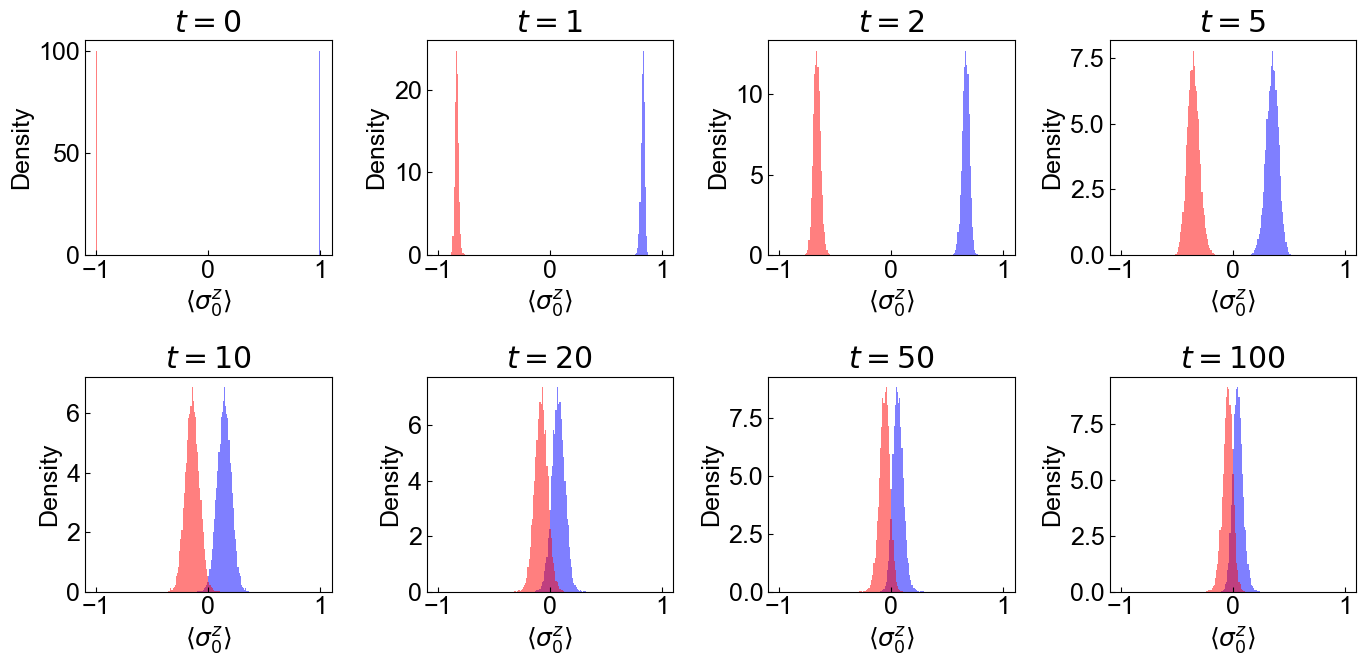

In [122]:
# Plot z magnetization histograms at different times
fig, axs = plt.subplots(2, 4, figsize=(14, 7), dpi=100)

for i in range(len(times_backward)):
    ax_curr = axs[i // 4, i % 4]
    bins = np.linspace(-1, 1, 201)
    ax_curr.hist([obs_time["z0"][i] for obs_time in obs_time_lst], bins=bins, density=True, color="blue", alpha=0.5)
    ax_curr.hist([-obs_time["z0"][i] for obs_time in obs_time_lst], bins=bins, density=True, color="red", alpha=0.5)
    ax_curr.set_title(f"$t={times_backward[i]:.0f}$")
    ax_curr.set_xlabel(r"$\langle \sigma_0^z \rangle$")
    ax_curr.set_ylabel("Density")

plt.tight_layout()
plt.show()

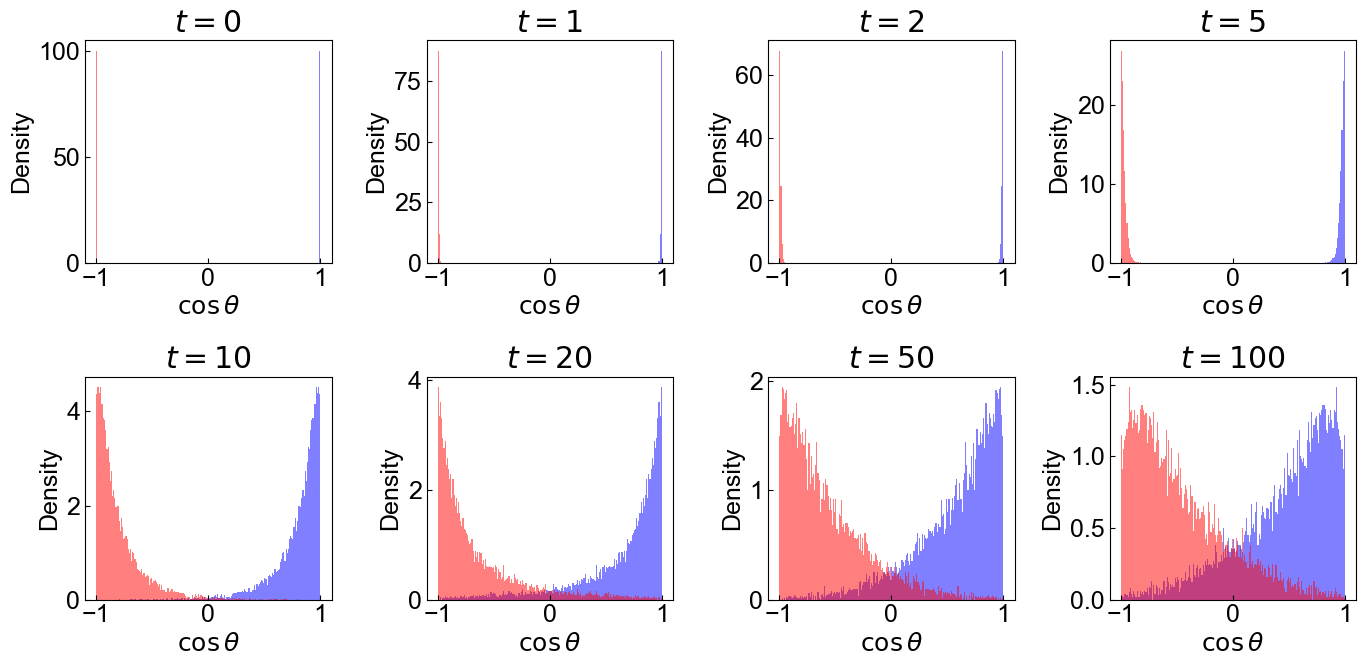

In [123]:
# Same as the above cell, but normalized by purity
fig, axs = plt.subplots(2, 4, figsize=(14, 7), dpi=100)

for i in range(len(times_backward)):
    ax_curr = axs[i // 4, i % 4]
    x0 = np.array([obs_time["x0"][i] for obs_time in obs_time_lst])
    y0 = np.array([obs_time["y0"][i] for obs_time in obs_time_lst])
    z0 = np.array([obs_time["z0"][i] for obs_time in obs_time_lst])
    purity = np.sqrt(x0 ** 2 + y0 ** 2 + z0 ** 2)
    bins = np.linspace(-1, 1, 201)
    ax_curr.hist(z0 / purity, bins=bins, density=True, color="blue", alpha=0.5)
    ax_curr.hist(-z0 / purity, bins=bins, density=True, color="red", alpha=0.5)
    ax_curr.set_title(f"$t={times_backward[i]:.0f}$")
    ax_curr.set_xlabel(r"$\cos\theta$")
    ax_curr.set_ylabel("Density")

plt.tight_layout()
plt.show()

C:\Users\matan\AppData\Local\Temp\ipykernel_32408\977366717.py:18: RuntimeWarning: invalid value encountered in divide
  prob_0 = h / (h + h_flip)


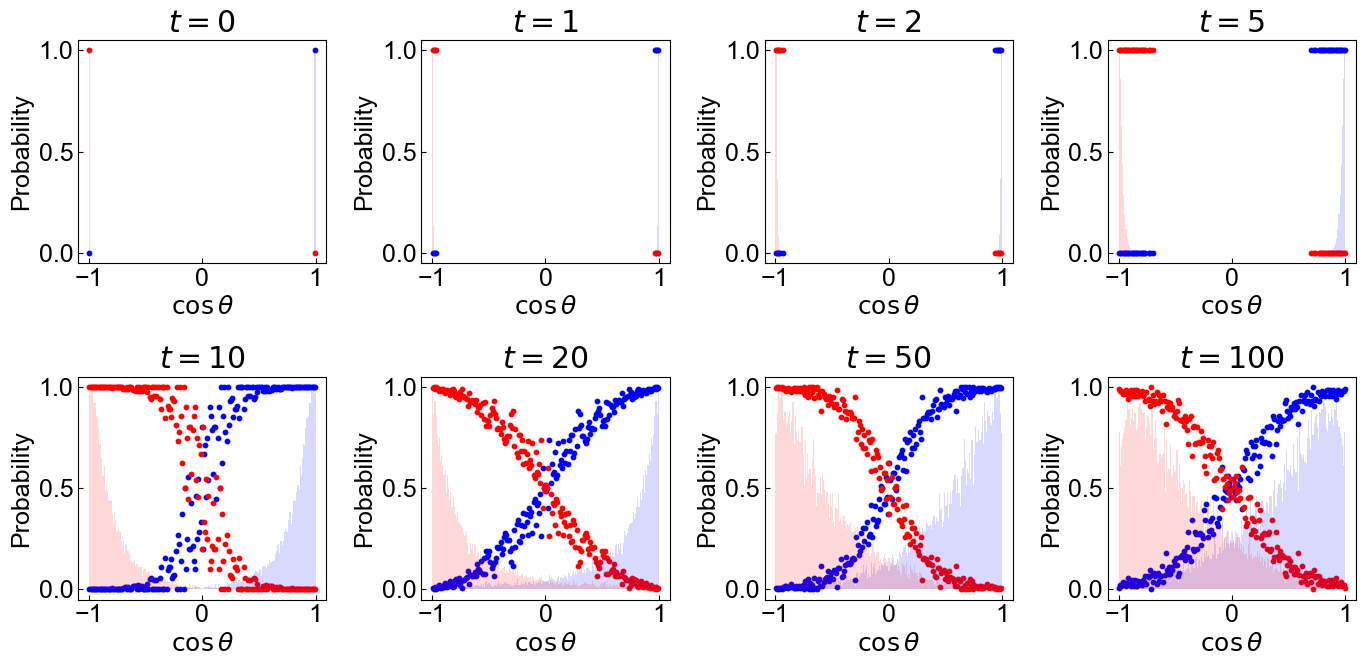

In [137]:
# Compute posterior collapse probabilities
fig, axs = plt.subplots(2, 4, figsize=(14, 7), dpi=100)

for i in range(len(times_backward)):
    ax_curr = axs[i // 4, i % 4]

    x0 = np.array([obs_time["x0"][i] for obs_time in obs_time_lst])
    y0 = np.array([obs_time["y0"][i] for obs_time in obs_time_lst])
    z0 = np.array([obs_time["z0"][i] for obs_time in obs_time_lst])
    purity = np.sqrt(x0 ** 2 + y0 ** 2 + z0 ** 2)

    bins = np.linspace(-1, 1, 201)
    h, _ = np.histogram(z0 / purity, bins=bins, density=True)
    h_flip, _ = np.histogram(-z0 / purity, bins=bins, density=True)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    # posterior probability
    prob_0 = h / (h + h_flip)

    # scatter posterior probabilities
    ax_curr.scatter(bin_centers, prob_0, color="b", s=10)
    ax_curr.scatter(bin_centers, 1 - prob_0, color="r", s=10)

    # show histograms
    width = bins[1] - bins[0]
    ax_curr.bar(bin_centers, h / np.max(h), width=width, alpha=0.15, color="blue", align="center")
    ax_curr.bar(bin_centers, h_flip / np.max(h_flip), width=width, alpha=0.15, color="red", align="center")
    valid = ~np.isnan(prob_0)
    if np.any(valid):
        xmin, xmax = bin_centers[valid].min(), bin_centers[valid].max()
        pad = max((xmax - xmin) * 0.05, 1e-3)
        ax_curr.set_xlim(xmin - pad, xmax + pad)
    ax_curr.set_ylim(-0.05, 1.05)
    ax_curr.set_title(f"$t={times_backward[i]:.0f}$")
    ax_curr.set_xlabel(r"$\cos\theta$")
    ax_curr.set_ylabel("Probability")

plt.tight_layout()
plt.show()

In [109]:
Z0 = collective_pauli(ha.basis, system_idx=0, coord="z")
Z0_exp_lst = Z0.expt_value(V, enforce_pure=True)

6.053376754143165e-16 -1.004993300937759e-09 1.0049954094467609e-09


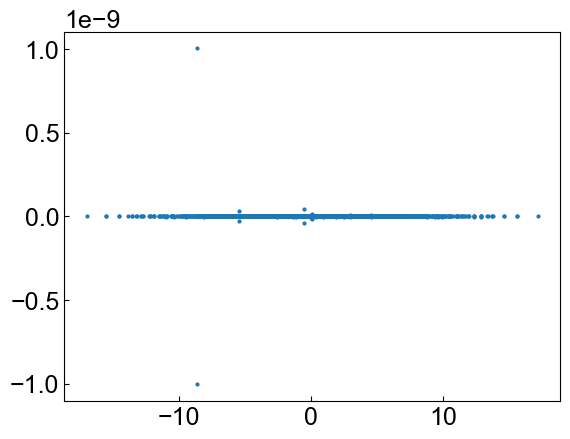

In [111]:
plt.scatter(E, Z0_exp_lst, s=4)
print(np.mean(Z0_exp_lst), np.min(Z0_exp_lst), np.max(Z0_exp_lst))

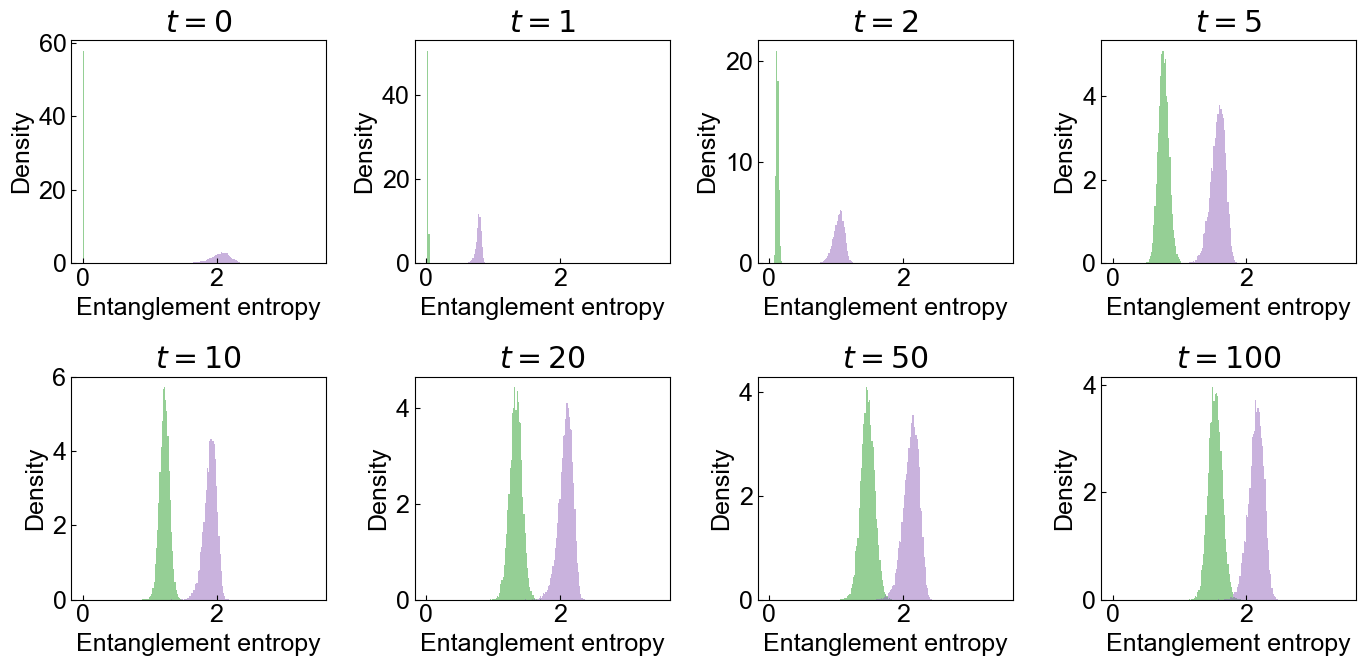

In [262]:
# Pixel entanglement entropy histogram at different times
fig, axs = plt.subplots(2, 4, figsize=(14, 7), dpi=100)
time_idx_to_plot = [0, 4, 5, 6, 7, 11, 12, 13]
for idx, i in enumerate(time_idx_to_plot):
    ax_curr = axs[idx // 4, idx % 4]
    bins = np.linspace(0, L * np.log(2), 201)
    ax_curr.hist([obs_time["ent_entropy_cond_0"][i] for obs_time in obs_time_lst], bins=bins, density=True, color="C2", alpha=0.5)
    ax_curr.hist([obs_time["ent_entropy_cond_1"][i] for obs_time in obs_time_lst], bins=bins, density=True, color="C4", alpha=0.5)
    ax_curr.set_title(f"$t={times_backward[i]:.0f}$")
    ax_curr.set_xlabel("Entanglement entropy")
    ax_curr.set_ylabel("Density")

plt.tight_layout()
plt.show()

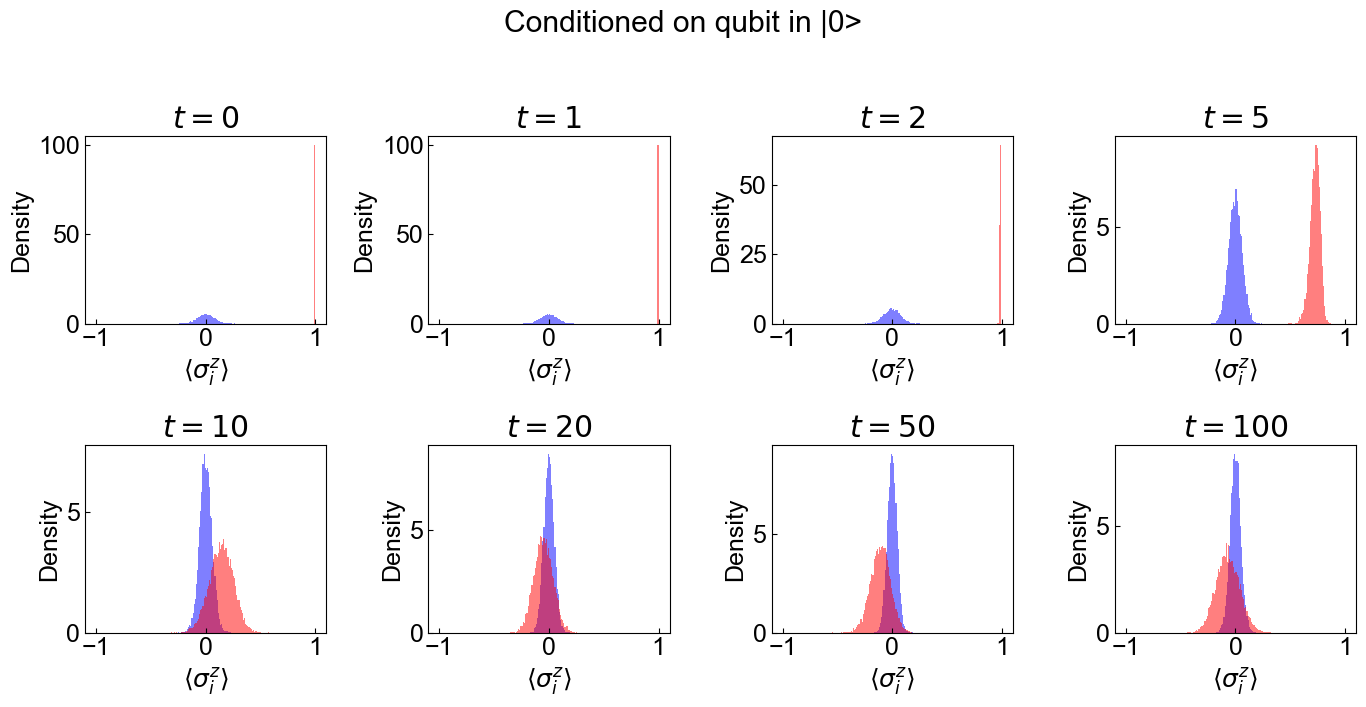

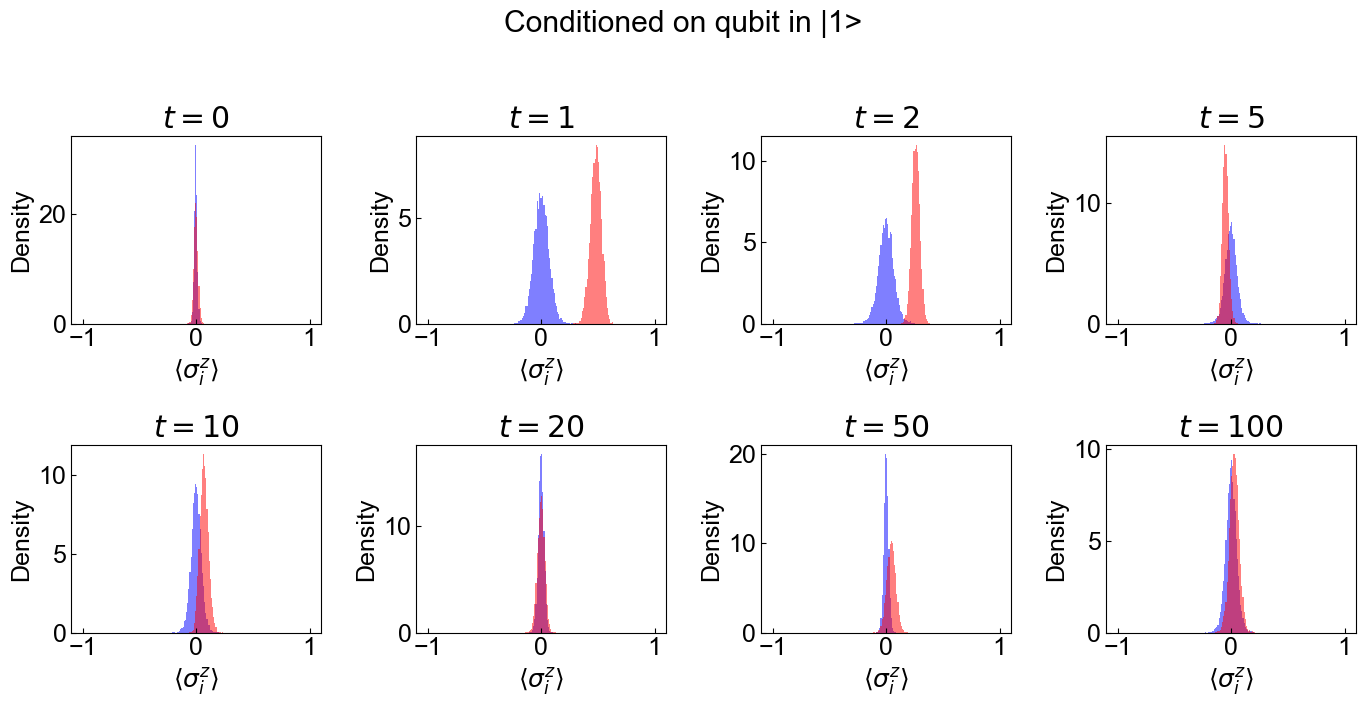

In [263]:
# Pixel magnetization histograms at different times
time_idx_to_plot = [0, 4, 5, 6, 7, 11, 12, 13]

# Conditioned on qubit in |0>
fig, axs = plt.subplots(2, 4, figsize=(14, 7), dpi=100)

for idx, i in enumerate(time_idx_to_plot):
    ax_curr = axs[idx // 4, idx % 4]
    bins = np.linspace(-1, 1, 201)
    ax_curr.hist([obs_time["z1_cond_0"][i] for obs_time in obs_time_lst], bins=bins, density=True, color="b", alpha=0.5)
    ax_curr.hist([obs_time["z2_cond_0"][i] for obs_time in obs_time_lst], bins=bins, density=True, color="r", alpha=0.5)
    ax_curr.set_title(f"$t={times_backward[i]:.0f}$")
    ax_curr.set_xlabel(r"$\langle \sigma_{i}^z \rangle$")
    ax_curr.set_ylabel("Density")

fig.suptitle("Conditioned on qubit in |0>", y=1.02)
plt.tight_layout()
plt.show()

# Conditioned on qubit in |1>
fig, axs = plt.subplots(2, 4, figsize=(14, 7), dpi=100)

for idx, i in enumerate(time_idx_to_plot):
    ax_curr = axs[idx // 4, idx % 4]
    bins = np.linspace(-1, 1, 201)
    ax_curr.hist([obs_time["z1_cond_1"][i] for obs_time in obs_time_lst], bins=bins, density=True, color="b", alpha=0.5)
    ax_curr.hist([obs_time["z2_cond_1"][i] for obs_time in obs_time_lst], bins=bins, density=True, color="r", alpha=0.5)
    ax_curr.set_title(f"$t={times_backward[i]:.0f}$")
    ax_curr.set_xlabel(r"$\langle \sigma_{i}^z \rangle$")
    ax_curr.set_ylabel("Density")

fig.suptitle("Conditioned on qubit in |1>", y=1.02)
plt.tight_layout()
plt.show()

## Stability of "purple algebra" states to perturbations

In [93]:
# System parameters
L = 6  # Number of spins in each pixel
hx = 1.1  # X latch-field strength on the pixel
hz = -0.3  # Z latch-field strength on the pixel
h1 = 0.0  # Z field strength on the first spin of each pixel
hL = 0.0  # Z field strength on the last spin of each pixel
g = 0.15  # Qubit-pixel coupling strength

# Construct and diagonalize the Hamiltonian
ha = construct_two_pixel_hamiltonian_analyzer(L=L, hx=hx, hz=hz, h1=h1, hL=hL, g=g)
E, V = ha.diagonalize(timeit=True)

# Compute a single "purple algebra" state
psi0 = create_final_collapsed_state(L, qubit_state=0, seed=0)
dt = 0.1
times = np.arange(0, 20 + dt, dt)
obs_time = compute_time_evolution_pauli(ha, times=times, psi0=psi0, eigvals=-E, eigvecs=V, verbose=True, return_state=True)
psi_t = obs_time["psi_t"]

Diagonalization took 204.5617 seconds.


In [104]:
print(V.shape, psi_t.dtype)

(8192, 8192) complex128


In [105]:
# Compute forward evolution for random-phase perturbations of the "purple algebra" state
def simulate_perturbed_forward_evolution(ha, psi0, times, eigvals, eigvecs, seed=0):
    rng = np.random.default_rng(seed)
    phases_diag = np.diag(np.exp(1j * 2 * np.pi * 0.5 * (rng.random(psi0.shape) - 0.5)))
    psi0_perturbed = eigvecs @ phases_diag @ np.conj(eigvecs.T) @ psi0
    obs_time_perturbed = compute_time_evolution_pauli(ha, times=times, psi0=psi0_perturbed, eigvals=eigvals, eigvecs=eigvecs, verbose=False, return_state=False)
    return obs_time_perturbed

num_perturb = 100

dt = 0.1
times = np.arange(0, 20 + dt, dt)

psi0_0 = create_final_collapsed_state(L, qubit_state=0, seed=0)
obs_time_0 = compute_time_evolution_pauli(ha, times=times, psi0=psi0_0, eigvals=-E, eigvecs=V, verbose=False, return_state=True)
psi_t_0 = obs_time_0["psi_t"]

psi0_1 = create_final_collapsed_state(L, qubit_state=1, seed=0)
obs_time_1 = compute_time_evolution_pauli(ha, times=times, psi0=psi0_1, eigvals=-E, eigvecs=V, verbose=False, return_state=True)
psi_t_1 = obs_time_1["psi_t"]

obs_time_perturbed_lst_0, obs_time_perturbed_lst_1 = [], []
dt = 0.1
times = np.arange(0, 40 + dt, dt)

obs_time_orig_0 = compute_time_evolution_pauli(ha, times=times, psi0=psi_t_0[:, -1], eigvals=E, eigvecs=V, verbose=False, return_state=False)
obs_time_perturbed_lst_0 = Parallel(n_jobs=4, verbose=20)(
    delayed(simulate_perturbed_forward_evolution)(
        ha=ha, psi0=psi_t_0[:, -1], times=times, eigvals=E, eigvecs=V, seed=i
    )  for i in range(num_perturb))

obs_time_orig_1 = compute_time_evolution_pauli(ha, times=times, psi0=psi_t_1[:, -1], eigvals=E, eigvecs=V, verbose=False, return_state=False)
obs_time_perturbed_lst_1 = Parallel(n_jobs=4, verbose=20)(
    delayed(simulate_perturbed_forward_evolution)(
        ha=ha, psi0=psi_t_1[:, -1], times=times, eigvals=E, eigvecs=V, seed=i
    )  for i in range(num_perturb))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


KeyboardInterrupt: 

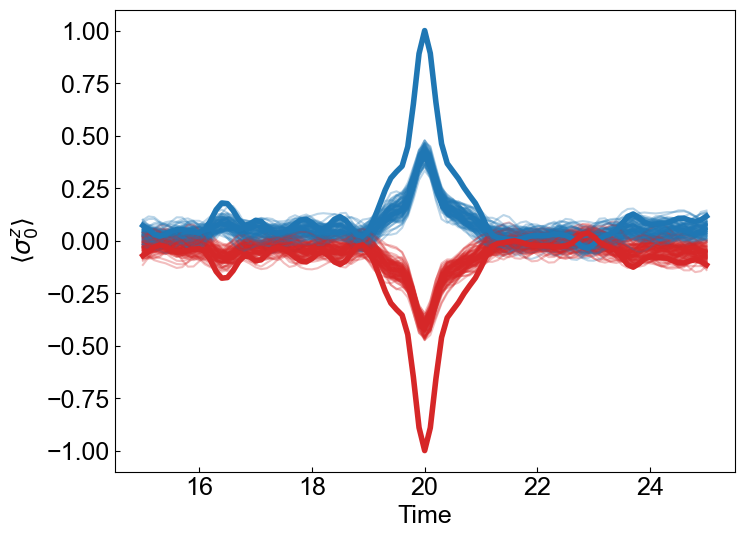

In [92]:
# Visualize realizations
t_mask = (times >= 15) & (times <= 25)
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
for i in range(num_perturb):
    obs_time_perturbed_0 = obs_time_perturbed_lst_0[i]
    obs_time_perturbed_1 = obs_time_perturbed_lst_1[i]
    ax.plot(times[t_mask], obs_time_perturbed_0["z0"][t_mask], color="C0", alpha=0.3)
    ax.plot(times[t_mask], obs_time_perturbed_1["z0"][t_mask], color="C3", alpha=0.3)
ax.plot(times[t_mask], obs_time_orig_0["z0"][t_mask], color="C0", lw=4)
ax.plot(times[t_mask], obs_time_orig_1["z0"][t_mask], color="C3", lw=4)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \sigma_0^z \rangle$")
plt.show()

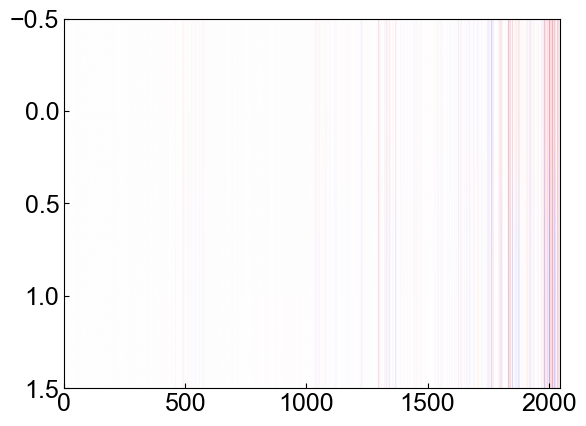

In [79]:
plt.imshow(np.real(V[[0, len(E) // 2], :]), aspect="auto", cmap="bwr")

## Time evolution of qubit and pixel magnetizations

In [ ]:
# Simulating for not extra qubit-pixel coupling (i.e., g=0)
L = 3  # Number of spins in each pixel
hx = 1.3  # X latch-field strength on the pixel
hz = -0.3  # Z field strength on the pixel
h1 = 0.25  # Z field strength on the first spin of each pixel
hL = -0.25  # Z field strength on the last spin of each pixel
g = 0. / L  # Qubit-pixel coupling strength

ha = construct_two_pixel_hamiltonian_analyzer(L, hx, hz, h1, hL, g)
N = ha.basis.Ns
eigvals, eigvecs = ha.diagonalize(timeit=True)

psi0 = np.zeros(N, dtype=np.complex128)
psi0[0] = 0.51
psi0[N // 2] = 0.49
dt = 0.1
times = np.arange(0, 20, dt)
res = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=2, pixel1_state="aligned", pixel2_state="melted", product_state=True,
        times=[t_final], seed=3 * (i + num_realizations)
    ) for i in range(num_realizations))

Diagonalization took 0.0549 seconds.
1.0
1.0
1.0
1j
1j


OpstrError: attemping to use real hamiltonian with complex matrix elements.

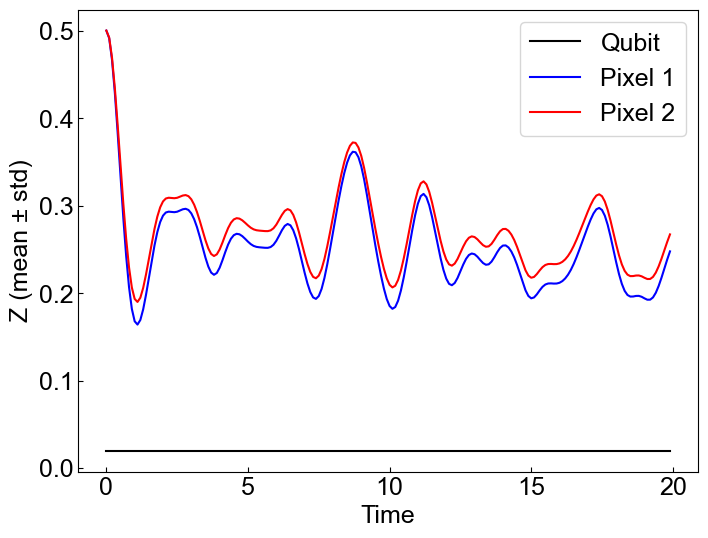

In [ ]:
# Visualize time evolution
eps = 1e-12  # small number to avoid sqrt of negative number
std_Z0 = np.sqrt(res["Z0_2"] - res["Z0"] ** 2 + eps)
std_Z1 = np.sqrt(res["Z1_2"] - res["Z1"] ** 2 + eps)
std_Z2 = np.sqrt(res["Z2_2"] - res["Z2"] ** 2 + eps)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
ax.plot(times, res["Z0"], color="k", label="Qubit")
# ax.fill_between(times, res["Z0"] - std_Z0, res["Z0"] + std_Z0, color="k", alpha=0.2)

ax.plot(times, res["Z1"], color="b", label="Pixel 1")
# ax.fill_between(times, res["Z1"] - std_Z1, res["Z1"] + std_Z1, color="b", alpha=0.2)

ax.plot(times, res["Z2"], color="r", label="Pixel 2")
# ax.fill_between(times, res["Z2"] - std_Z2, res["Z2"] + std_Z2, color="r", alpha=0.2)

ax.set_xlabel("Time")
ax.set_ylabel(r"Z (mean ± std)")

ax.legend()
plt.show()

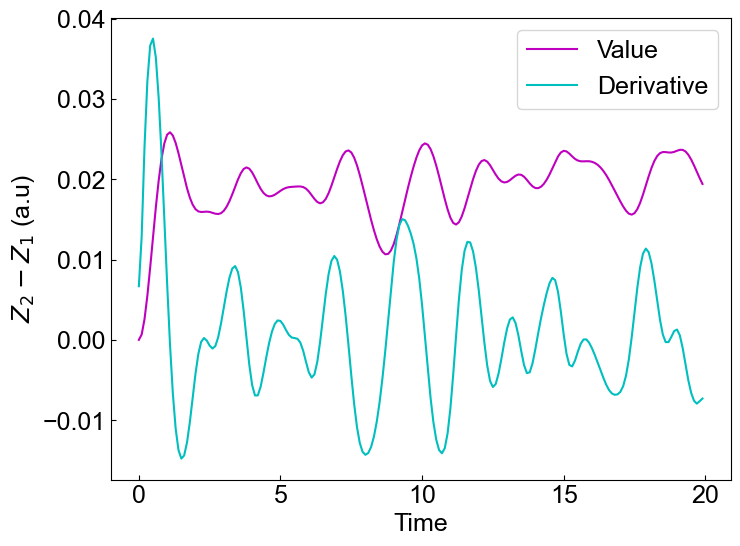

In [480]:
# Visualize the difference between the Z-magnetizations of the two pixels
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
Z_diff = res["Z2"] - res["Z1"]
Z_diff_deriv = np.gradient(Z_diff, dt)
ax.plot(times, Z_diff, color="m", label="Value")
ax.plot(times, Z_diff_deriv, color="c", label="Derivative")
ax.set_xlabel("Time")
ax.set_ylabel(r"$Z_2 - Z_1$ (a.u)")
ax.legend()
plt.show()

## Characterizing the "purple algebra"

In [ ]:
def generate_initial_system_state(L, qubit_state, pixel1_state, pixel2_state, product_state=True, seed=0):
    """
    Generates an initial state vector for the two-pixel system with specified qubit and pixel configurations.

    Parameters:
        L (int): Number of spins in each pixel.
        qubit_state (str): Initial state of the qubit (1 or 2).
        pixel1_state (str): Initial state of pixel 1 ('aligned' or 'melted').
        pixel2_state (str): Initial state of pixel 2 ('aligned' or 'melted').
        product_state (bool, optional): If True, pixels are in a product state; if False, may be entangled.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        np.ndarray: Initial state vector of the full system (shape (N,)).
    """

    # Initial qubit state
    if qubit_state == 1:
        psi0_qubit = np.array([1, 0], dtype=np.complex128)
    elif qubit_state == 2:
        psi0_qubit = np.array([0, 1], dtype=np.complex128)
    else:
        raise ValueError("Invalid qubit state. Choose 1 or 2.")

    # Initial pixel states
    sg = StateGenerator()
    if product_state:
        # Pixel #1
        if pixel1_state == "aligned":
            psi0_pixel1 = np.zeros(2 ** L, dtype=np.complex128)
            psi0_pixel1[0] = 1.0  # All spins up
        elif pixel1_state == "melted":
            psi0_pixel1 = sg.create_haar_random_state(L, seed=seed)
        else:
            raise ValueError("Invalid pixel1 state. Choose 'aligned' or 'melted'.")
        
        # Pixel #2
        if pixel2_state == "aligned":
            psi0_pixel2 = np.zeros(2 ** L, dtype=np.complex128)
            psi0_pixel2[0] = 1.0  # All spins up
        elif pixel2_state == "melted":
            psi0_pixel2 = sg.create_haar_random_state(L, seed=seed + 1)
        else:
            raise ValueError("Invalid pixel2 state. Choose 'aligned' or 'melted'.")
        
        psi0_pixels = np.kron(psi0_pixel1, psi0_pixel2)
    else:
        psi0_pixels = sg.create_haar_random_state(2 * L, seed=seed + 2)

    return np.kron(psi0_qubit, psi0_pixels)

In [281]:
# System parameters
L = 3  # Number of spins in each pixel
hx = 1.3  # X latch-field strength on the pixel
hz = -0.3  # Z field strength on the pixel
h1 = 0.  # Z field strength on the first spin of each pixel
hL = -0.  # Z field strength on the last spin of each pixel
g = 1. / L  # Qubit-pixel coupling strength

t_final = 1e6  # Long time corresponding to final state
num_realizations = 10 ** 3

# Diagonalize the Hamiltonian once
ha = construct_two_pixel_hamiltonian_analyzer(L, hx, hz, h1, hL, g)
N = ha.basis.Ns
E, V = ha.diagonalize(timeit=True)

# Simulate various scenarios in parallel
def compute_final_state(ha, eigvals, eigvecs, qubit_state, pixel1_state, pixel2_state, product_state, times, seed):
    L = ha.basis.N[1]  # Number of spins in each pixel
    psi0 = generate_initial_system_state(L, qubit_state=qubit_state,
                                         pixel1_state=pixel1_state,
                                         pixel2_state=pixel2_state,
                                         product_state=product_state, seed=seed)
    return compute_time_evolution_pauli(ha=ha, times=times, psi0=psi0,
                                        eigvals=eigvals, eigvecs=eigvecs,
                                        verbose=False, return_state=False)

# Pixel 1 melted, pixel 2 aligned
res_1a = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=1, pixel1_state="melted", pixel2_state="aligned", product_state=True,
        times=[t_final], seed=3 * i
    ) for i in range(num_realizations))

# Pixel 2 melted, pixel 1 aligned
res_2a = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=2, pixel1_state="aligned", pixel2_state="melted", product_state=True,
        times=[t_final], seed=3 * (i + num_realizations)
    ) for i in range(num_realizations))

# Both pixels melted and in product state, qubit in |0>
res_1p = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=1, pixel1_state="melted", pixel2_state="melted", product_state=True,
        times=[t_final], seed=3 * (i + 2 * num_realizations)
    ) for i in range(num_realizations))

# Both pixels melted and in product state, qubit in |1>
res_2p = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=2, pixel1_state="melted", pixel2_state="melted", product_state=True,
        times=[t_final], seed=3 * (i + 3 * num_realizations)
    ) for i in range(num_realizations))

# Both pixels melted and entangled, qubit in |0>
res_1e = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=1, pixel1_state="melted", pixel2_state="melted", product_state=False,
        times=[t_final], seed=3 * (i + 4 * num_realizations)
    ) for i in range(num_realizations))

# Both pixels melted and entangled, qubit in |1>
res_2e = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=2, pixel1_state="melted", pixel2_state="melted", product_state=False,
        times=[t_final], seed=3 * (i + 5 * num_realizations)
    ) for i in range(num_realizations))

Hermiticity check passed!
Diagonalization took 0.0627 seconds.


c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\core.py:102: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  return hamiltonian(static_list=self.static, dynamic_list=[], basis=self.basis, dtype=np.float64)
c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\core.py:102: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  return hamiltonian(static_list=self.static, dynamic_list=[], basis=self.basis, dtype=np.float64)
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   15.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   15.8s
[Parallel(n_jobs=4)]: Done  17 tasks      | 

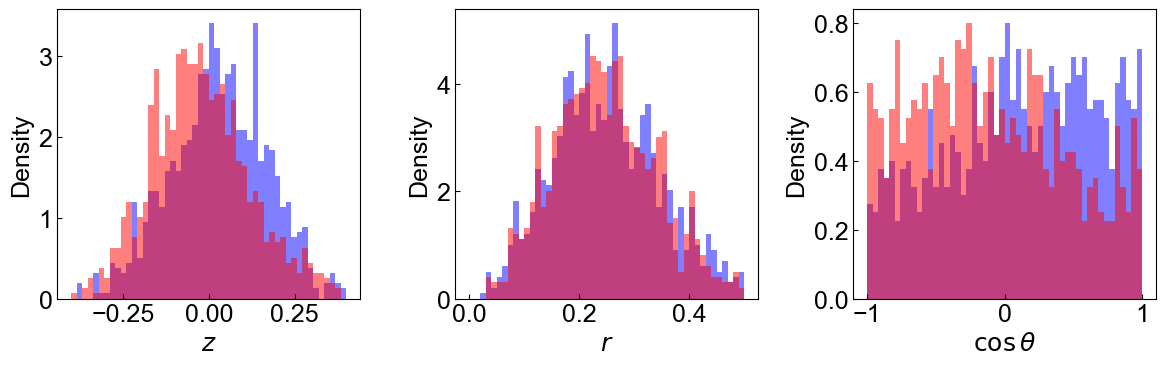

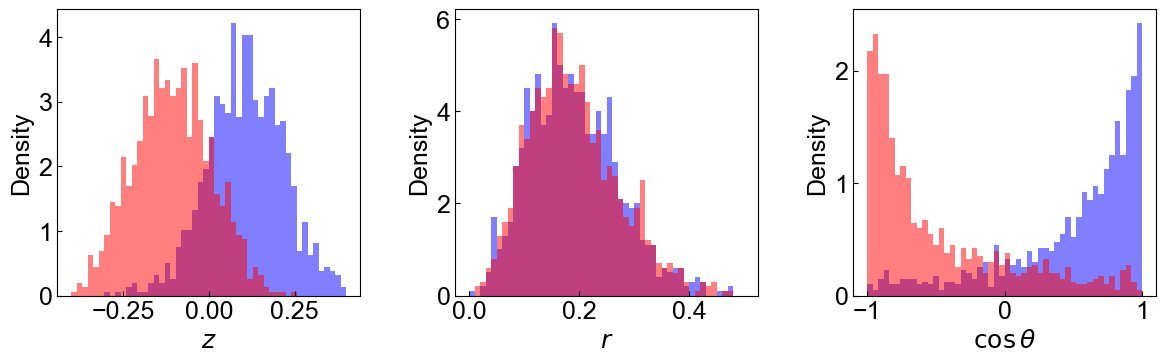

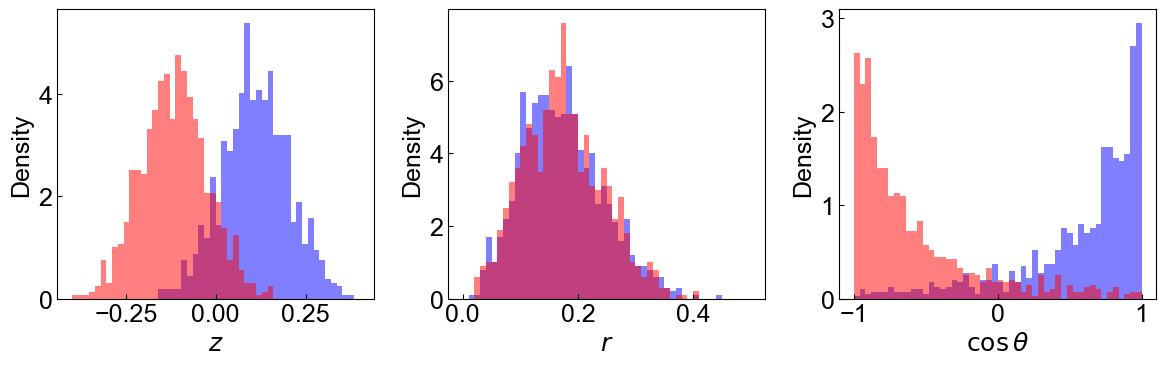

In [282]:
def unpack_observable(res_list, observable):
    return np.array([res[observable][0] for res in res_list])

# Compare histograms of Z0, the qubit's purity and cos(theta) in various scenarios
def plot_final_state_histograms(res1, res2):
    x1 = unpack_observable(res1, "X0")
    y1 = unpack_observable(res1, "Y0")
    z1 = unpack_observable(res1, "Z0")
    x2 = unpack_observable(res2, "X0")
    y2 = unpack_observable(res2, "Y0")
    z2 = unpack_observable(res2, "Z0")
    
    r1 = np.sqrt(x1 ** 2 + y1 ** 2 + z1 ** 2)
    r2 = np.sqrt(x2 ** 2 + y2 ** 2 + z2 ** 2)

    u1 = z1 / (r1 + 1e-12)
    u2 = z2 / (r2 + 1e-12)

    fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)
    num_bins = 50
    bins_z = np.linspace(-0.4, 0.4, num_bins + 1)
    hist_z1, _, _ = axs[0].hist(z1, bins=bins_z, density=True, alpha=0.5, color="b")
    hist_z2, _, _ = axs[0].hist(z2, bins=bins_z, density=True, alpha=0.5, color="r")
    axs[0].set_xlabel("$z$")
    axs[0].set_ylabel("Density")

    bins_r = np.linspace(0, 0.5, num_bins + 1)
    hist_r1, _, _ = axs[1].hist(r1, bins=bins_r, density=True, alpha=0.5, color="b")
    hist_r2, _, _ = axs[1].hist(r2, bins=bins_r, density=True, alpha=0.5, color="r")
    axs[1].set_xlabel("$r$")
    axs[1].set_ylabel("Density")

    bins_u = np.linspace(-1, 1, num_bins + 1)
    hist_u1, _, _ = axs[2].hist(u1, bins=bins_u, density=True, alpha=0.5, color="b")
    hist_u2, _, _ = axs[2].hist(u2, bins=bins_u, density=True, alpha=0.5, color="r")
    axs[2].set_xlabel(r"$\cos\theta$")
    axs[2].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

    return {
        "z": (hist_z1, hist_z2, bins_z),
        "r": (hist_r1, hist_r2, bins_r),
        "u": (hist_u1, hist_u2, bins_u)
    }

# One pixel melted, other aligned
hist_data_a = plot_final_state_histograms(res_1a, res_2a)

# Both pixels melted and in product state
hist_data_p = plot_final_state_histograms(res_1p, res_2p)

# Both pixels melted and entangled
hist_data_e = plot_final_state_histograms(res_1e, res_2e)

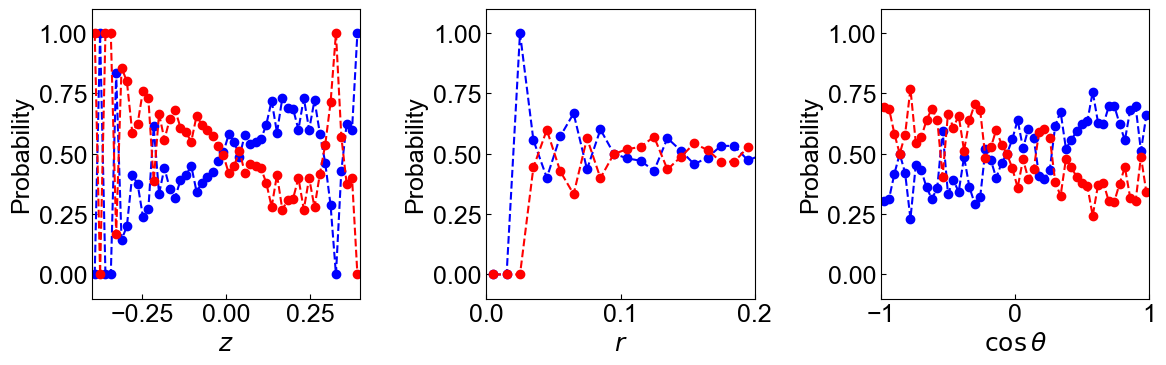

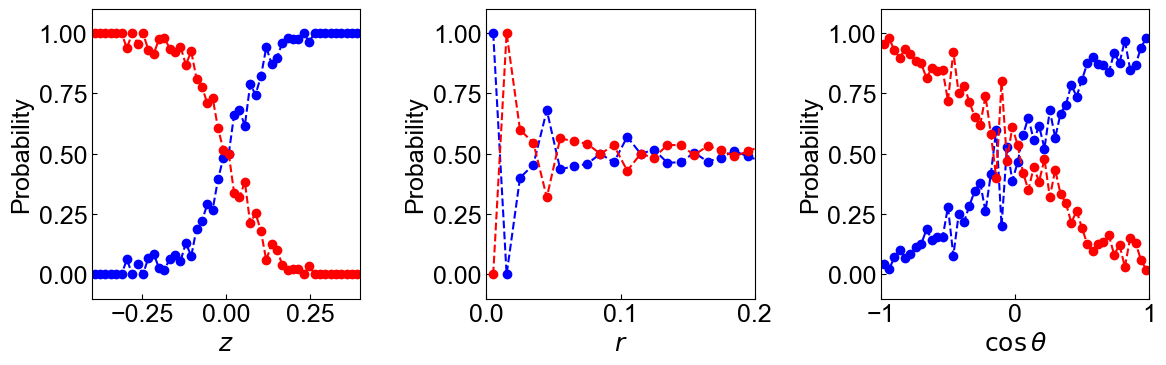

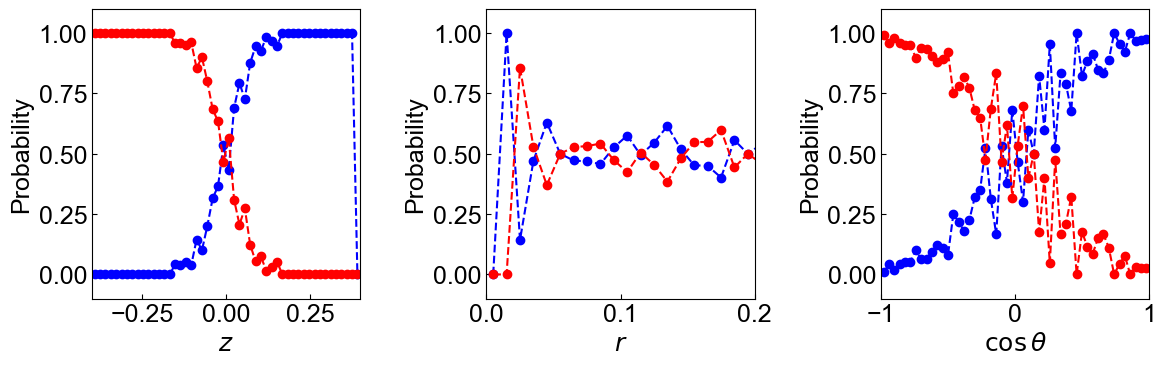

In [283]:
# Compare posterior distributions
def plot_posterior_probabilities(hist_data):
    zs = 0.5 * (hist_data["z"][2][1:] + hist_data["z"][2][:-1])
    rs = 0.5 * (hist_data["r"][2][1:] + hist_data["r"][2][:-1])
    us = 0.5 * (hist_data["u"][2][1:] + hist_data["u"][2][:-1])

    h1_zs, h2_zs = hist_data["z"][0], hist_data["z"][1]
    h1_rs, h2_rs = hist_data["r"][0], hist_data["r"][1]
    h1_us, h2_us = hist_data["u"][0], hist_data["u"][1]

    fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)

    axs[0].plot(zs, h1_zs / (h1_zs + h2_zs + 1e-12), color="b", linestyle="--", marker="o")
    axs[0].plot(zs, h2_zs / (h1_zs + h2_zs + 1e-12), color="r", linestyle="--", marker="o")
    axs[0].set_xlim(-0.4, 0.4)
    axs[0].set_ylim(-0.1, 1.1)
    axs[0].set_xlabel("$z$")
    axs[0].set_ylabel("Probability")
    

    axs[1].plot(rs, h1_rs / (h1_rs + h2_rs + 1e-12), color="b", linestyle="--", marker="o")
    axs[1].plot(rs, h2_rs / (h1_rs + h2_rs + 1e-12), color="r", linestyle="--", marker="o")
    axs[1].set_xlim(0, 0.2)
    axs[1].set_ylim(-0.1, 1.1)
    axs[1].set_xlabel("$r$")
    axs[1].set_ylabel("Probability")

    axs[2].plot(us, h1_us / (h1_us + h2_us + 1e-12), color="b", linestyle="--", marker="o")
    axs[2].plot(us, h2_us / (h1_us + h2_us + 1e-12), color="r", linestyle="--", marker="o")
    axs[2].set_xlim(-1, 1)
    axs[2].set_ylim(-0.1, 1.1)
    axs[2].set_xlabel(r"$\cos\theta$")
    axs[2].set_ylabel("Probability")
    
    plt.tight_layout()
    plt.show()

# One pixel melted, other aligned
plot_posterior_probabilities(hist_data_a)

# Both pixels melted and in product state
plot_posterior_probabilities(hist_data_p)

# Both pixels melted and entangled
plot_posterior_probabilities(hist_data_e)

In [295]:
# Compare time evolutions of different realizations
L = 5  # Number of spins in each pixel
hx = 1.3  # X latch-field strength on the pixel
hz = -0.3  # Z field strength on the pixel
h1 = 0.  # Z field strength on the first spin of each pixel
hL = -0.  # Z field strength on the last spin of each pixel
g = 1. / L  # Qubit-pixel coupling strength

dt = 0.1
times = np.arange(0, 50, dt)
num_realizations = 10

# Diagonalize the Hamiltonian
ha = construct_two_pixel_hamiltonian_analyzer(L, hx, hz, h1, hL, g)
N = ha.basis.Ns
E, V = ha.diagonalize(timeit=True)

res_lst = []
for i in tqdm(range(num_realizations)):
    psi0 = generate_initial_system_state(L, qubit_state=1,
                                         pixel1_state="melted",
                                         pixel2_state="aligned",
                                         product_state=True, seed=3 * i)
    res = compute_time_evolution_pauli(ha=ha, times=times, psi0=psi0,
                                      eigvals=E, eigvecs=V,
                                      verbose=False, return_state=False)
    res_lst.append(res)

Hermiticity check passed!
Diagonalization took 4.7207 seconds.


100%|██████████| 10/10 [03:40<00:00, 22.02s/it]


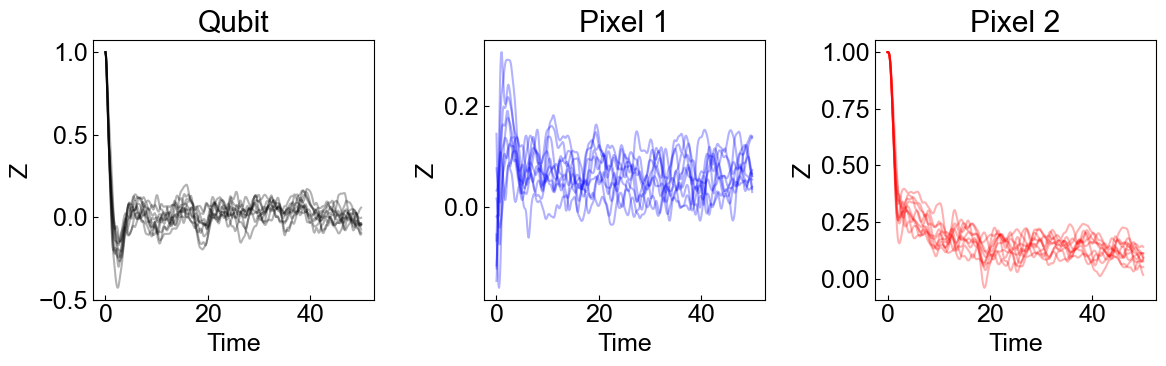

In [298]:
# Visualize different realizations
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)
for res in res_lst:
    axs[0].plot(times, res["Z0"], color="k", alpha=0.3)
    axs[1].plot(times, res["Z1"], color="b", alpha=0.3)
    axs[2].plot(times, res["Z2"], color="r", alpha=0.3)

for ax in axs:
    ax.set_xlabel("Time")
    ax.set_ylabel("Z")

axs[0].set_title("Qubit")
axs[1].set_title("Pixel 1")
axs[2].set_title("Pixel 2")

plt.tight_layout()
plt.show()

In [503]:
# Repeat for shorter time range and more realizations
L = 5  # Number of spins in each pixel
hx = 1.3  # X latch-field strength on the pixel
hz = -0.3  # Z field strength on the pixel
h1 = 0.25  # Z field strength on the first spin of each pixel
hL = -0.25  # Z field strength on the last spin of each pixel
g = 1. / L  # Qubit-pixel coupling strength

dt = 1.
times = np.arange(1e6, 1e6 + 1000, dt)
num_realizations = 10

# Diagonalize the Hamiltonian
ha = construct_two_pixel_hamiltonian_analyzer(L, hx, hz, h1, hL, g)
N = ha.basis.Ns
E, V = ha.diagonalize(timeit=True)

res1_lst = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=1, pixel1_state="melted", pixel2_state="aligned", product_state=True,
        times=times, seed=3 * i
    ) for i in range(num_realizations))

res2_lst = Parallel(n_jobs=4, verbose=10)(
    delayed(compute_final_state)(
        ha=ha, eigvals=E, eigvecs=V, qubit_state=2, pixel1_state="aligned", pixel2_state="melted", product_state=True,
        times=times, seed=3 * (i + num_realizations)
    ) for i in range(num_realizations))

Hermiticity check passed!
Diagonalization took 4.7945 seconds.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 out of  10 | elapsed:  3.9min remaining:  3.9min
[Parallel(n_jobs=4)]: Done   7 out of  10 | elapsed:  3.9min remaining:  1.7min
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:  4.9min finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 out of  10 | elapsed:  3.7min remaining:  3.7min
[Parallel(n_jobs=4)]: Done   7 out of  10 | elapsed:  3.7min remaining:  1.6min
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:  4.7min finished


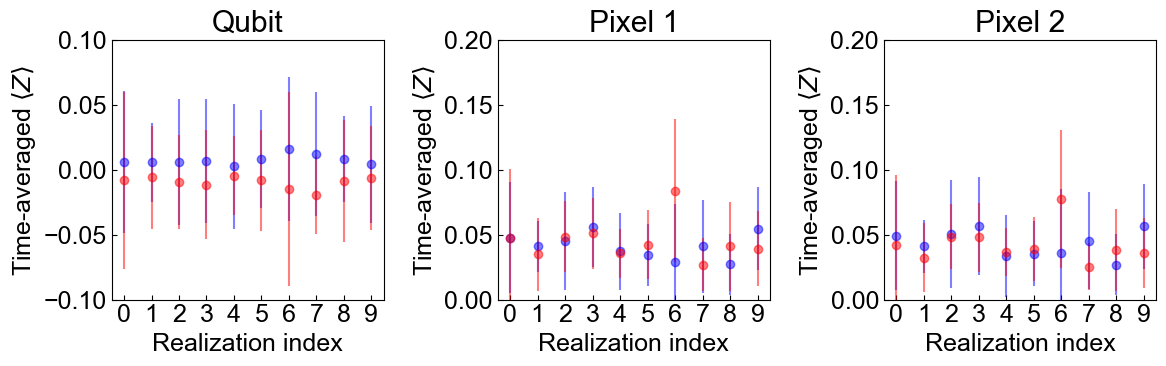

In [505]:
# Plot mean and std of different realizations
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)

for i in range(3):
    z1 = [np.mean(res[f"Z{i}"]) for res in res1_lst]
    z2 = [np.mean(res[f"Z{i}"]) for res in res2_lst]
    dt1 = [np.std(res[f"Z{i}"]) for res in res1_lst]
    dt2 = [np.std(res[f"Z{i}"]) for res in res2_lst]
    axs[i].errorbar(range(num_realizations), z1, yerr=dt1, fmt="o", color="b", alpha=0.5)
    axs[i].errorbar(range(num_realizations), z2, yerr=dt2, fmt="o", color="r", alpha=0.5)

for ax in axs:
    ax.set_xlabel("Realization index")
    ax.set_ylabel(r"Time-averaged $\langle Z \rangle$")
    ax.set_xticks(range(0, num_realizations))

axs[0].set_ylim(-0.1, 0.1)
axs[1].set_ylim(0, 0.2)
axs[2].set_ylim(0, 0.2)

axs[0].set_title("Qubit")
axs[1].set_title("Pixel 1")
axs[2].set_title("Pixel 2")

plt.tight_layout()
plt.show()

In [497]:
# Another approach: Using the diagonal ensemble to compute long-time averages
L = 5  # Number of spins in each pixel
hx = 1.3  # X latch-field strength on the pixel
hz = -0.3  # Z field strength on the pixel
h1 = 0.25  # Z field strength on the first spin of each pixel
hL = -0.25  # Z field strength on the last spin of each pixel
g = 1. / L  # Qubit-pixel coupling strength

num_realizations = 10

# Diagonalize the Hamiltonian
ha = construct_two_pixel_hamiltonian_analyzer(L, hx, hz, h1, hL, g)
N = ha.basis.Ns
E, V = ha.diagonalize(timeit=True)

res1_lst, res2_lst, res3_lst = [], [], []
obs_dict = {
        "Z0": hamiltonian([["z||", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False, check_pcon=False),
        "Z1": hamiltonian([["|z|", [[1.0 / L, i] for i in range(L)]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False, check_pcon=False),
        "Z2": hamiltonian([["||z", [[1.0 / L, i] for i in range(L)]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False, check_pcon=False)
    }
for i in tqdm(range(num_realizations)):
    psi0 = generate_initial_system_state(L, qubit_state=1,
                                         pixel1_state="melted",
                                         pixel2_state="aligned",
                                         product_state=True, seed=3 * i)
    Z0_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z0"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    Z1_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z1"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    Z2_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z2"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    res1_lst.append((Z0_diag, Z1_diag, Z2_diag))

for i in tqdm(range(num_realizations)):
    psi0 = generate_initial_system_state(L, qubit_state=2,
                                         pixel1_state="aligned",
                                         pixel2_state="melted",
                                         product_state=True, seed=3 * (i + num_realizations))
    Z0_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z0"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    Z1_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z1"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    Z2_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z2"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    res2_lst.append((Z0_diag, Z1_diag, Z2_diag))

for i in tqdm(range(num_realizations)):
    psi0 = generate_initial_system_state(L, qubit_state=1,
                                         pixel1_state="aligned",
                                         pixel2_state="aligned",
                                         product_state=True, seed=3 * (i + 2 * num_realizations))
    Z0_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z0"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    Z1_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z1"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    Z2_diag = diag_ensemble(N=2 * L + 1, system_state=psi0, E2=E, V2=V, Obs=obs_dict["Z2"], density=False, delta_q_Obs=True, delta_t_Obs=True)
    res3_lst.append((Z0_diag, Z1_diag, Z2_diag))

Hermiticity check passed!
Diagonalization took 9.3699 seconds.


100%|██████████| 10/10 [02:07<00:00, 12.79s/it]


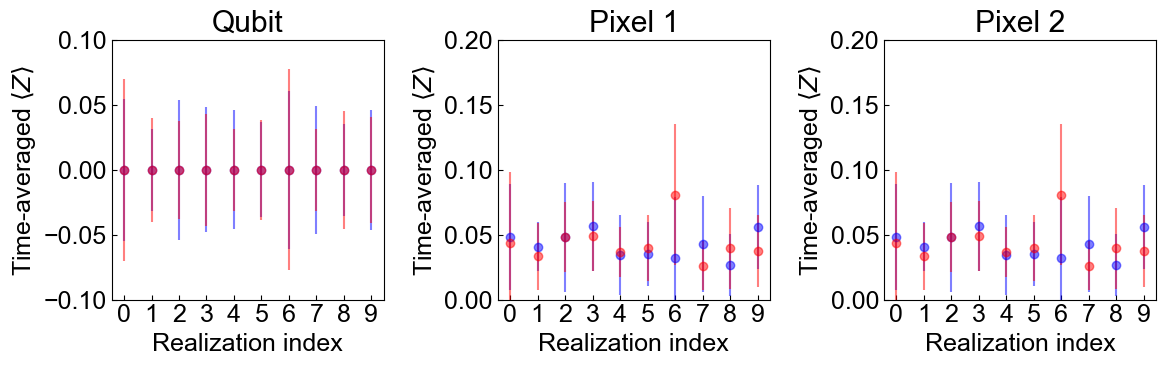

In [498]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)

for i in range(3):
    z1 = [res[i]["Obs_pure"] for res in res1_lst]
    z2 = [res[i]["Obs_pure"] for res in res2_lst]
    
    dt1 = [res[i]["delta_t_Obs_pure"] for res in res1_lst]
    dt2 = [res[i]["delta_t_Obs_pure"] for res in res2_lst]
    dq1 = [res[i]["delta_q_Obs_pure"] for res in res1_lst]
    dq2 = [res[i]["delta_q_Obs_pure"] for res in res2_lst]
    axs[i].errorbar(range(num_realizations), z1, yerr=dt1, fmt="o", color="b", alpha=0.5)
    axs[i].errorbar(range(num_realizations), z2, yerr=dt2, fmt="o", color="r", alpha=0.5)

for ax in axs:
    ax.set_xlabel("Realization index")
    ax.set_ylabel(r"Time-averaged $\langle Z \rangle$")
    ax.set_xticks(range(0, num_realizations))

axs[0].set_ylim(-0.1, 0.1)
axs[1].set_ylim(0, 0.2)
axs[2].set_ylim(0, 0.2)

axs[0].set_title("Qubit")
axs[1].set_title("Pixel 1")
axs[2].set_title("Pixel 2")

plt.tight_layout()
plt.show()